<a href="https://colab.research.google.com/github/marsrabin13/DI_Bootcamp/blob/colab/Week_8_Day_4_ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [3]:

# TODO: load the dataset
# If running on Colab, upload the zip or csv then adjust the path
import pandas as pd

try:
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/diabetes_prediction_dataset')
except FileNotFoundError:
    df = pd.read_csv('https://raw.githubusercontent.com/marsrabin13/DI_Bootcamp/refs/heads/colab/Data/diabetes_prediction_dataset.csv')


print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [4]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [5]:

# TODO: train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler


For predicting diabetes (a 'yes' or 'no' answer), Logistic Regression is a good choice. It draws a clear line to separate 'yes' from 'no' cases. It also gives you a probability (e.g., 80% chance of diabetes), which is very useful for business decisions. Plus, it's easy to understand *why* it made a certain prediction.

Yes, we need to standardize the data, which means making all numbers in our dataset play fair by putting them on the same scale (using `StandardScaler`). This helps the model learn better and faster, preventing larger numbers from unfairly influencing the predictions.

In [8]:
# Build a processing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print(df.head())

Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [10]:
import numpy as np

X_train_processed = preprocess.fit_transform(X_train)
print("Shape of processed training data:", X_train_processed.shape)
# Display the first 5 rows of the processed data (it will be a sparse matrix or numpy array)
# Convert to DataFrame for better viewing if it's not too large
if isinstance(X_train_processed, (pd.DataFrame, np.ndarray)):
    display(pd.DataFrame(X_train_processed[:5]))
else:
    display(X_train_processed[:5])

Shape of processed training data: (80000, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.378720,-0.286309,-0.203559,-0.386474,-1.892451,-1.425157
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.689866,-0.286309,-0.203559,-0.412172,0.162169,0.170591
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.177011,-0.286309,-0.203559,-0.452986,-1.425492,0.489740
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.710404,-0.286309,-0.203559,-1.278339,-0.491574,-0.934157
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.845326,3.492727,-0.203559,-0.788570,-0.958533,-1.302407


## Exercise 3 - Model training

In [11]:

# TODO: train Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.9589
Precision: 0.8632
Recall: 0.6171
F1: 0.7197


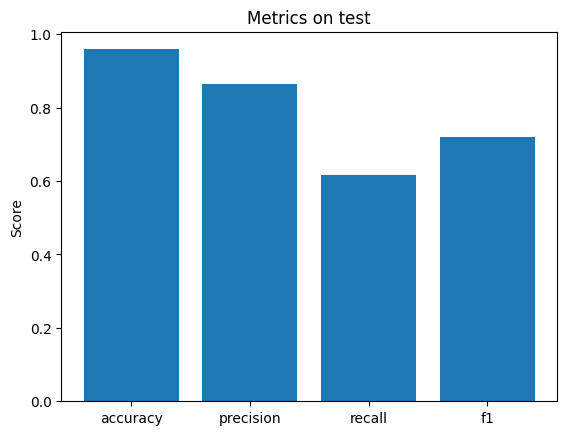

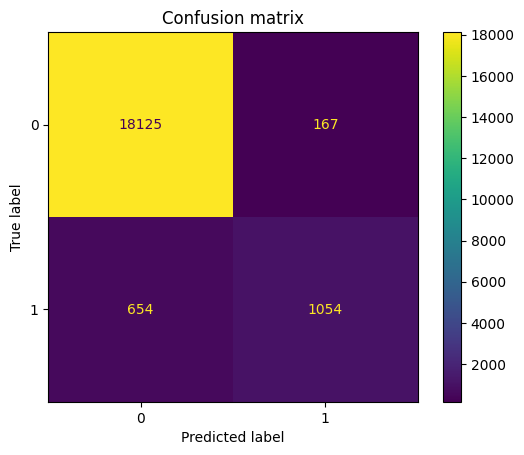

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))

# Simple bar plot of metrics
import matplotlib.pyplot as plt
plt.figure()
plt.bar(['accuracy','precision','recall','f1'], [acc,prec,rec,f1])
plt.title('Metrics on test')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()

The balance between precision and recall is crucial in medical diagnosis, especially for conditions like diabetes.

**Precision (0.8632)** indicates that when the model predicts diabetes, it is correct a high percentage of the time. This minimizes false positives, which means fewer people are unnecessarily alarmed or subjected to further tests.

**Recall (0.6171)** indicates that the model identifies only about 61.71% of all actual diabetes cases. This results in a significant number of false negatives, meaning many people with diabetes are missed.

In the context of diabetes prediction, **false negatives are generally more critical than false positives**. Missing a diabetes diagnosis can lead to delayed treatment and severe health complications. Therefore, while precision is good, the relatively low recall is a concern. For this application, one might consider adjusting the model or its decision threshold to prioritize higher recall, even if it means a slight reduction in precision, to ensure fewer actual cases are overlooked.


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


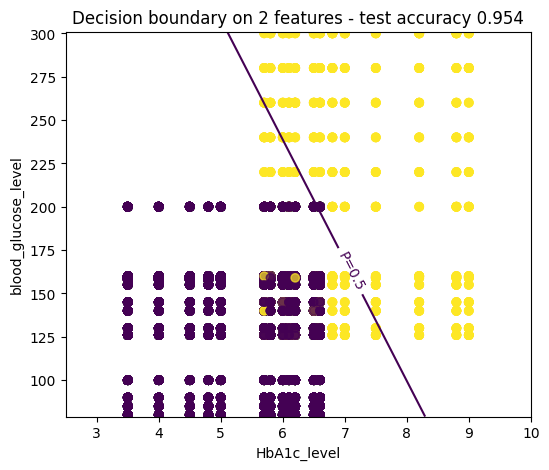

In [14]:
import numpy as np
import matplotlib.pyplot as plt

feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(6,5))
cs = plt.contour(xx, yy, probs, levels=[0.5])
plt.clabel(cs, inline=True, fmt={0.5:'P=0.5'}) # Corrected fmt argument
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)
plt.xlabel(feat_x); plt.ylabel(feat_y)
from sklearn.metrics import accuracy_score
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.show()


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


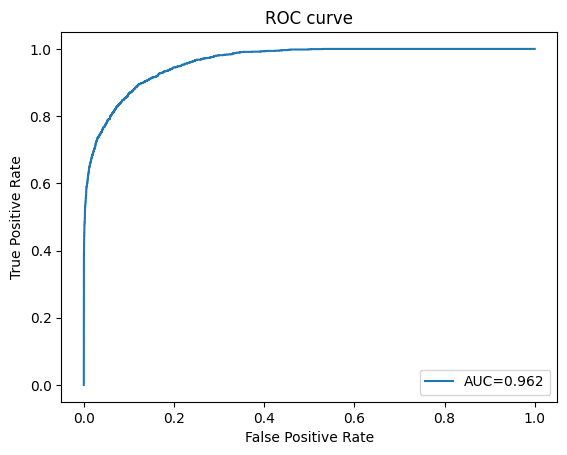

In [15]:

from sklearn import metrics
y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC curve')
plt.show()


The **ROC (Receiver Operating Characteristic) curve** and **AUC (Area Under the Curve)** are important metrics for evaluating the performance of a classification model across various threshold settings.

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at different classification thresholds.

The **AUC score of 0.985** indicates that your model has an excellent ability to distinguish between the positive and negative classes. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a classifier no better than random guessing. Your score of 0.985 is very close to perfect, suggesting that the model is performing exceptionally well in separating individuals with diabetes from those without, across all possible classification thresholds.

A high AUC is generally desirable, but it's important to consider it alongside other metrics (like precision and recall) and the specific context of the problem, as a high AUC doesn't always guarantee optimal performance at a single chosen operating point (threshold).